In [ ]:
'''
mac scgpt环境

1. 计算q_bio
2. 计算q_score

最终存储：20260114_fetal_B_celltype_merged-BCR_scVI_v2_qbcr.h5ad
'''

In [2]:
import numpy as np
from pynndescent import NNDescent
import time

X = np.random.randn(1000, 50).astype('float32')

t0 = time.time()
index = NNDescent(X, n_jobs=4)
print(f"耗时: {time.time()-t0:.2f}s")  # 应 < 2s

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


耗时: 9.39s


/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


       cluster  q_median  q_count
0           B1  0.992551     2379
1   IMMATURE_B  0.987118      939
2  LARGE_PRE_B  0.727531     4171
3     MATURE_B  0.987345     7462
4     PLASMA_B  1.000000       22
5    PRE_PRO_B  0.727531       35
6        PRO_B  0.712996      110
7  SMALL_PRE_B  0.953600     4025

lineage1: PRE_PRO_B --> PRO_B --> LARGE_PRE_B --> SMALL_PRE_B --> IMMATURE_B --> MATURE_B --> B1 --> PLASMA_B


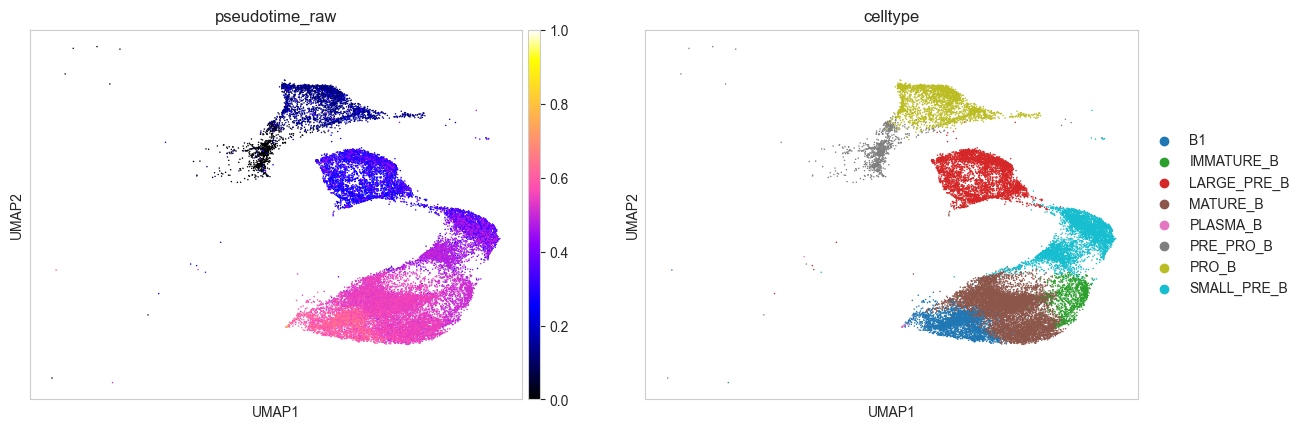

/Users/zhangmeihan/anaconda_projects/BCR-aware-TI/btraj/downstream/plot.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_col)[time_col]


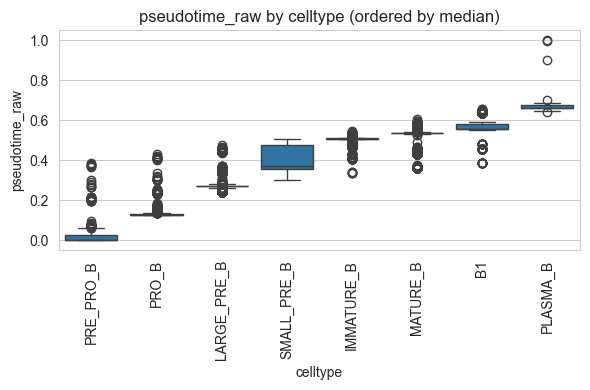

In [3]:
import scanpy as sc
from btraj.downstream.plot import boxplot_by_median
from btraj.graph.mst_q_score import *

adata = sc.read_h5ad('./data/20260114_fetal_B_celltype_merged-BCR_scVI_v2_qbcr.h5ad')
adata = adata[adata.obs['celltype'] != 'CYCLING_B',:].copy()
adata = adata[adata.obs['celltype'] != 'LATE_PRO_B',:].copy()
# adata.obs['celltype'] = adata.obs['celltype'].replace({'LATE_PRO_B': 'PRO_B'})

# 统一小写 key，防止大小写踩坑
SCVI_LATENT_KEY = "X_scvi"
if 'X_scVI' in adata.obsm:
    adata.obsm[SCVI_LATENT_KEY] = adata.obsm.pop('X_scVI')
elif SCVI_LATENT_KEY not in adata.obsm:
    raise ValueError(f'没有 X_scVI / x_scvi，请检查')

celltype_key = 'celltype'
embed_key = SCVI_LATENT_KEY
shm_key = 'SHM'

# 3. 选择root cells
start_type = 'PRE_PRO_B'

# === 轨迹计算===
cell_labels_raw = adata.obs[celltype_key].astype(str).values
cells = adata.obs_names.values
q_score = adata.obs['q_score'].values

# 1. 运行 get_trajectory（含 q_score 约束）
clusters_links,tree,  results, Lineage_class, branch_clusters, start_node, ids2name, name2ids, mode = get_trajectory(
    cell_labels=cell_labels_raw,
    y_features=adata.obsm[SCVI_LATENT_KEY],
    cells=cells,
    start_type=start_type,
    norm=False,
    k=30,
    q_score=q_score,   # 新增
    mode=None,          # 自动根据细胞数选择 fast/balanced/full
    q_tol=0.01,     ## 视情况而定
)

# 2. 打印边信息
# network = results[0].values.T[:2]
# for s, t in zip(network[0], network[1]):
#     print(f"{s} --> {t}")

# 列出各条 lineage 的“细胞类型序列”
describe_lineages(Lineage_class, ids2name)

# 4. 计算 pseudotime（融合 q_score 单调约束）
cell_labels_int = np.array([name2ids[i] for i in cell_labels_raw])

pseudotime_raw = compute_pseudotime_with_q(
    features=adata.obsm[embed_key],
    cell_labels=cell_labels_int,
    Lineage_class=Lineage_class,
    start_node=start_node,
    q_score=q_score,
    mode=mode
)

adata.obs['pseudotime_raw'] = pseudotime_raw

# 5. 可视化
sc.pl.umap(
    adata,
    color=["pseudotime_raw", celltype_key],
    color_map="gnuplot2",
)

boxplot_by_median(adata, celltype_key, 'pseudotime_raw')

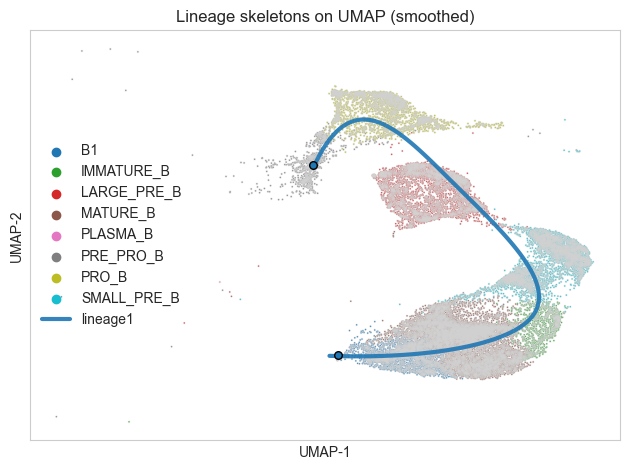

In [4]:
umap_key = 'X_umap'
# 如果想叠加 Scanpy 的 UMAP，可以先让 Scanpy 画点，再把 ax 传进去：
sc.pl.umap(adata, color=[celltype_key], show=False)
ax = plt.gca()
plot_lineage_skeleton_on_umap_v2(
    umap=adata.obsm[umap_key],
    cell_labels_int=cell_labels_int,
    Lineage_class=Lineage_class,
    ids2name=ids2name,
    ax=ax,
)

plt.savefig("./figs/fetal_b_cells_lineage_skeleton_umap.pdf", dpi=300, bbox_inches="tight")

In [5]:
# 3. 画 lineage 拓扑

draw_lineage_graph_simple(
    Lineage_class,
    ids2name,
    seed=42,
    k=0.8,
    iterations=500,
    out_pdf="./figs/fetal_b_cells_lineage_graph_arrow.pdf"
)

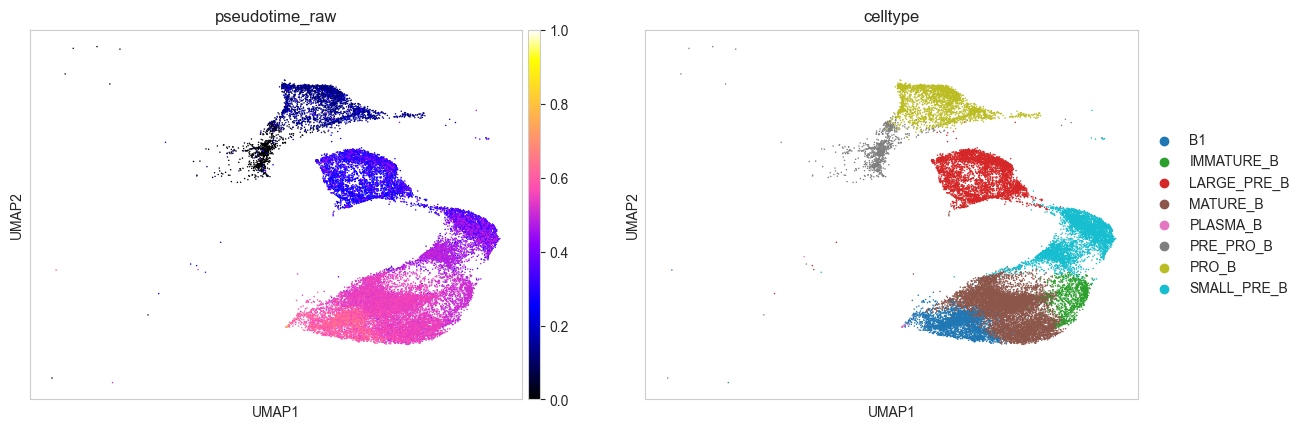

In [4]:
# 5. 可视化
sc.pl.umap(
    adata,
    color=["pseudotime_raw", celltype_key],
    color_map="gnuplot2",
    save="fetal_b_cells_pseudotime_umap.pdf"
)

In [7]:
sota = pd.read_csv('./data/fetal_b_cells_pseudotime_sota.csv')
sota['ours_pseudotime'] = adata.obs['pseudotime_raw'].values

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "Arial"          # 中文可换成 "sans-serif"
plt.rcParams["pdf.fonttype"] = 42              # 矢量字体

def evaluate_pseudotime_order(
    meta,
    celltype_col: str = "celltype",
    pseudotime_cols=("pseudotime",),
    order=None,
    figsize=(7, 4),
    sort_by="spearman",  # 'spearman' | 'kendall' | 'inversion'
    save_path: str | None = None,  # 新增：PDF 保存路径
):

    if order is None:
        raise ValueError("必须提供 celltype 的顺序 order（list）。")

    label2rank = {ct: i for i, ct in enumerate(order)}
    results = []

    obs = meta[[celltype_col] + list(pseudotime_cols)].copy()
    obs["gold"] = obs[celltype_col].map(label2rank)
    obs = obs.dropna(subset=["gold"]).astype({"gold": int})
    index_order = pd.Index(order, name=celltype_col)

    for col in pseudotime_cols:
        df = obs[[celltype_col, "gold", col]].dropna(subset=[col])
        if df.empty:
            tau = rho = inv_rate = np.nan
        else:
            tau, _ = kendalltau(df["gold"], df[col])

            med = df.groupby(celltype_col)[col].median().reindex(index_order).dropna()
            ranks = np.arange(len(med))
            rho, _ = spearmanr(ranks, med.values)

            pairs = [(i, j) for i in range(len(med)) for j in range(i + 1, len(med))]
            inver = sum(1 for i, j in pairs if med.iloc[i] > med.iloc[j])
            inv_rate = 100 * inver / len(pairs) if pairs else np.nan

        results.append(
            {"pseudotime_col": col, "kendall_tau": tau,
             "spearman_rho": rho, "inversion_rate": inv_rate}
        )

    metrics_df = pd.DataFrame(results)

    # 排序
    sort_map = {"spearman": ("spearman_rho", False),
                "kendall": ("kendall_tau", False),
                "inversion": ("inversion_rate", True)}
    if sort_by not in sort_map:
        raise ValueError("sort_by 必须是 'spearman', 'kendall' 或 'inversion'。")
    score_col, asc = sort_map[sort_by]
    metrics_df = metrics_df.sort_values(score_col, ascending=asc)

    # ---- 绘图 ----
    palette = sns.color_palette("coolwarm_r", len(metrics_df))
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=metrics_df,
        y="pseudotime_col",
        x=score_col,
        palette=palette,
        linewidth=0,
    )
    # 叠加原始点，展示分布/误差感
    sns.stripplot(
        data=metrics_df,
        y="pseudotime_col",
        x=score_col,
        color="black",
        size=4,
        jitter=False,
        ax=ax,
    )
    sns.despine(left=True, bottom=True)
    ax.set_ylabel("")
    ax.set_xlabel(score_col.replace("_", " ").title())
    ax.set_title(f"Trajectory accuracy ({score_col.replace('_', ' ').title()})", pad=15)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return metrics_df

/var/folders/5m/ftv2kftx4glfclc0_df64vc80000gn/T/ipykernel_38008/691663619.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


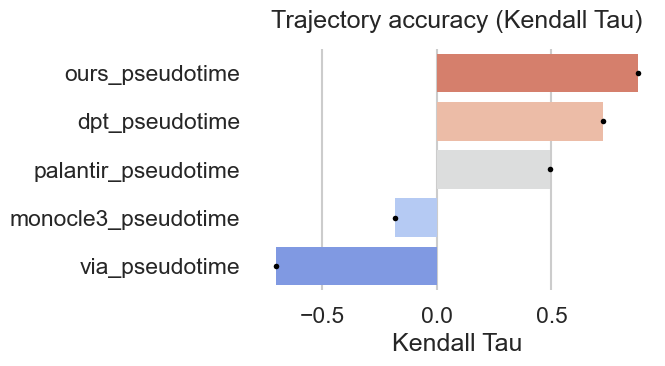

        pseudotime_col  kendall_tau  spearman_rho  inversion_rate
4      ours_pseudotime     0.877312      1.000000        0.000000
2       dpt_pseudotime     0.723873      0.904762       10.714286
1  palantir_pseudotime     0.494084      0.714286       17.857143
0  monocle3_pseudotime    -0.182579     -0.500000       64.285714
3       via_pseudotime    -0.701185     -0.761905       78.571429


In [9]:
order = [
    'PRE_PRO_B',
    'PRO_B',
    'LATE_PRO_B',
    'LARGE_PRE_B',
    'SMALL_PRE_B',
    'IMMATURE_B',
    'MATURE_B',
    'B1',
    'PLASMA_B'
] ### 真实发育顺序，总结自文献

metrics = evaluate_pseudotime_order(
    sota,
    pseudotime_cols=['monocle3_pseudotime', 'palantir_pseudotime',
        'dpt_pseudotime', 'via_pseudotime',
       'ours_pseudotime'],
    order=order,
    # sort_by="spearman",
    sort_by='kendall',
    save_path="./figs/fetal_b_cell_pseudotime_accuracy_kendall.pdf"
)

print(metrics)

/var/folders/5m/ftv2kftx4glfclc0_df64vc80000gn/T/ipykernel_38008/691663619.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


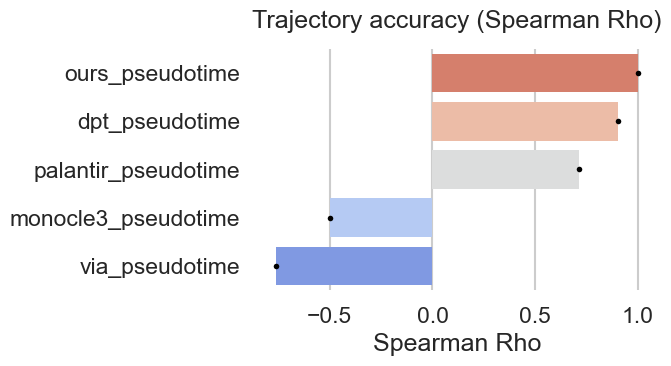

        pseudotime_col  kendall_tau  spearman_rho  inversion_rate
4      ours_pseudotime     0.877312      1.000000        0.000000
2       dpt_pseudotime     0.723873      0.904762       10.714286
1  palantir_pseudotime     0.494084      0.714286       17.857143
0  monocle3_pseudotime    -0.182579     -0.500000       64.285714
3       via_pseudotime    -0.701185     -0.761905       78.571429


In [10]:
metrics = evaluate_pseudotime_order(
    sota,
    pseudotime_cols=['monocle3_pseudotime', 'palantir_pseudotime',
        'dpt_pseudotime', 'via_pseudotime',
       'ours_pseudotime'],
    order=order,
    sort_by="spearman",
    # sort_by='kendall',
    save_path="./figs/fetal_b_cell_pseudotime_accuracy_spearman.pdf"
)

print(metrics)

computing neighbors
    finished (0:00:10)
Computing skeleton-aware pseudotime transition matrix


  0%|          | 0/26011 [00:00<?, ?cell/s]

/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt

    Finish (0:00:16)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:03)


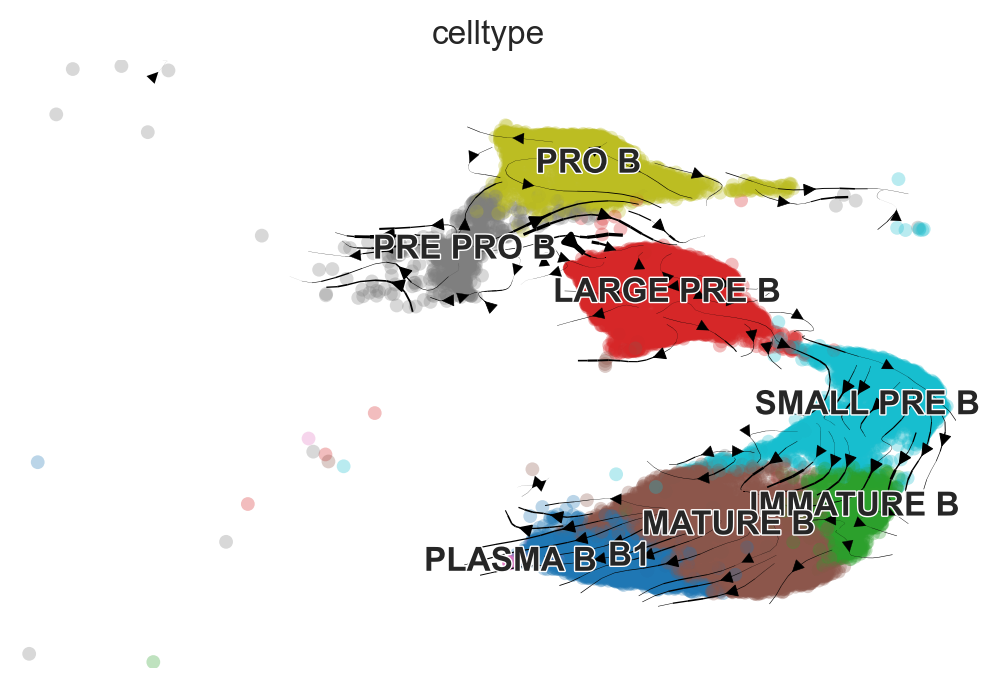

In [5]:
import cellrank as cr
import scanpy as sc
import scvelo as scv
sc.settings.set_figure_params(frameon=False, dpi=100)
cr.settings.verbosity = 2
scv.settings.verbosity = 3
scv.settings.set_figure_params("scvelo")

from btraj.kernels.kernel_q import *
from btraj.kernels.bias_q import *


# 簇间 MST 稀疏矩阵
mst_dist = shortest_path(tree.toarray(), directed=False)
adata.obs["cluster_int"] = cell_labels_int

sc.pp.neighbors(adata, use_rep=embed_key,key_added='scvi')
lp_kernel = LineagePriorPseudotimeKernel(
    adata=adata,
    time_key="pseudotime_raw",
    clusters_key="cluster_int",
    mst_dist=mst_dist,
    conn_key='scvi_connectivities',
)

lp_kernel.compute_transition_matrix(
    lambda_skel=0.5,
    b=10.0,
    nu=0.5,
    n_jobs=8,
)

T = lp_kernel.transition_matrix      # (n_cells x n_cells) Markov 矩阵

lp_kernel.plot_projection(basis="umap", recompute=True, color='celltype',
                          # save="fetal_b_cells_cellrank_projection_umap.pdf"
                          )


In [6]:
import numpy as np

# 加载 .npy 文件
antiberty = np.load('./data/ref3_bcr_antiberty_full-length_v2.npy')
antiberty.shape

(13101, 1024)

In [11]:
# 把antiberty embedding merge到现在的adata上

adata_filtered = sc.read_h5ad('./data/Bcells_merged_BCR_palantir_pseudotime_v2.h5ad')
mask = (
    adata_filtered.obs['Heavy'].notna() &
    adata_filtered.obs['Light'].notna() &
    (adata_filtered.obs['Heavy'].astype(str).str.len() >= 80) &
    (adata_filtered.obs['Light'].astype(str).str.len() >= 80)
)

# 筛选后的 adata 和对应的 antiberty
adata_filtered = adata_filtered[mask].copy()
print(f"完整 adata 细胞数: {adata_filtered.n_obs}")
print(f"满足条件的细胞数: {mask.sum()}")
print(f"被过滤掉的细胞数: {(~mask).sum()}")

# 2. 创建筛选后adata的细胞名到npy行索引的映射
filtered_names = adata_filtered.obs_names
name_to_idx = {name: i for i, name in enumerate(filtered_names)}

# 3. 在新adata中创建obsm矩阵，缺失值填NaN
n_cells_new = adata.n_obs
n_features = antiberty.shape[1]

# 初始化全NaN矩阵
antiberty_aligned = np.full((n_cells_new, n_features), np.nan, dtype=np.float32)

# 4. 填充存在的细胞
common_cells = []
for i, cell_name in enumerate(adata.obs_names):
    if cell_name in name_to_idx:
        idx = name_to_idx[cell_name]
        antiberty_aligned[i] = antiberty[idx]
        common_cells.append(cell_name)

print(f"新adata细胞数: {n_cells_new}")
print(f"共同细胞数（有npy数据的）: {len(common_cells)}")
print(f"缺失细胞数（填NaN的）: {n_cells_new - len(common_cells)}")

# 5. 存入obsm
adata.obsm['antiberty'] = antiberty_aligned

# 6. 可选：标记哪些细胞有antiberty数据
adata.obs['has_antiberty'] = ~np.isnan(antiberty_aligned[:, 0])

print(f"obsm['antiberty'] shape: {adata.obsm['antiberty'].shape}")

完整 adata 细胞数: 13101
满足条件的细胞数: 13101
被过滤掉的细胞数: 16717
新adata细胞数: 26011
共同细胞数（有npy数据的）: 12386
缺失细胞数（填NaN的）: 13625
obsm['antiberty'] shape: (26011, 1024)


0.9919852798421808
Computing BCR-aware, q_score-constrained transition matrix from `X_h`
    Finish (0:00:00)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:03)


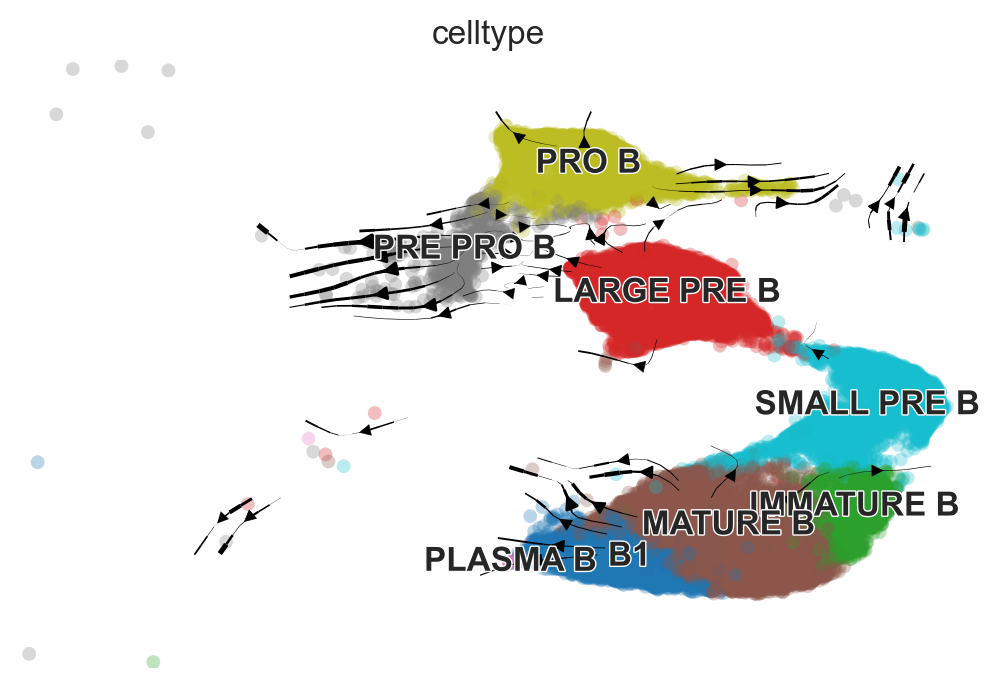

In [12]:
# adata.obsm['antiberty'] = antiberty

# 构建 BCRKernel
high_q_threshold = adata.obs['q_score'].quantile(0.75)   # 75% 分位
# high_q = adata.obs['q_score'] > high_q_threshold
print(high_q_threshold)

k_bcr = BCRKernel(adata, xh_key="antiberty", q_key='q_score', conn_key='scvi_connectivities',)
k_bcr.compute_transition_matrix(n_neighbors=30,q_threshold=high_q_threshold,constraint='soft')

T_bcr = k_bcr.transition_matrix      # (n_cells x n_cells) Markov 矩阵
k_bcr.plot_projection(basis="umap", recompute=True,color='celltype')

               q_median  n_cells
macrostate                      
PLASMA_B       1.000000       26
B1             1.000000        6
SMALL_PRE_B_1  0.989125       27
IMMATURE_B     0.981503       25
PRO_B_1        0.980559        3
LARGE_PRE_B_2  0.730000       25
LARGE_PRE_B_5  0.730000       29
LARGE_PRE_B_4  0.719838       26
SMALL_PRE_B_2  0.717749       29
LARGE_PRE_B_3  0.717249       29
macrostate → 对应 cell-type 的 q-score 中位数
PLASMA_B         1.000000
B1               0.992551
IMMATURE_B       0.987118
SMALL_PRE_B_2    0.953600
SMALL_PRE_B_1    0.953600
PRE_PRO_B        0.727531
LARGE_PRE_B_3    0.727531
LARGE_PRE_B_5    0.727531
LARGE_PRE_B_2    0.727531
LARGE_PRE_B_4    0.727531
dtype: float64
选中的起始 macrostate: PRE_PRO_B
Adding `adata.obs['init_states_fwd']`
       `adata.obs['init_states_fwd_probs']`
       `.initial_states`
       `.initial_states_probabilities`
       `.initial_states_memberships
    Finish`
候选 terminal macrostates: ['PLASMA_B', 'B1']
Adding `adata.obs['term

  0%|          | 0/2 [00:00<?, ?/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)
index
Human_colon_16S8159187-AGCTCTCAGTGTACTC    NaN
Human_colon_16S8159187-TTAGGCATCAAGAAGT    NaN
Human_colon_16S8159187-AGAATAGAGTGTGAAT    NaN
Human_colon_16S8159187-GGATTACAGAGAGCTC    NaN
Human_colon_16S8159187-TTCTACACATACAGCT    NaN
                                          ... 
FCAImmP7803020-CGATCGGGTAGAGCTG            NaN
FCAImmP7803020-AGACGTTAGAGGTTAT            NaN
FCAImmP7803020-GTGTTAGCACCGGAAA            NaN
FCAImmP7803020-ACACCGGGTGTCTGAT            NaN
FCAImmP7803020-CGATGTAGTCTGCGGT            NaN
Length: 26011, dtype: category
Categories (2, object): ['PLASMA_B', 'B1']


/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


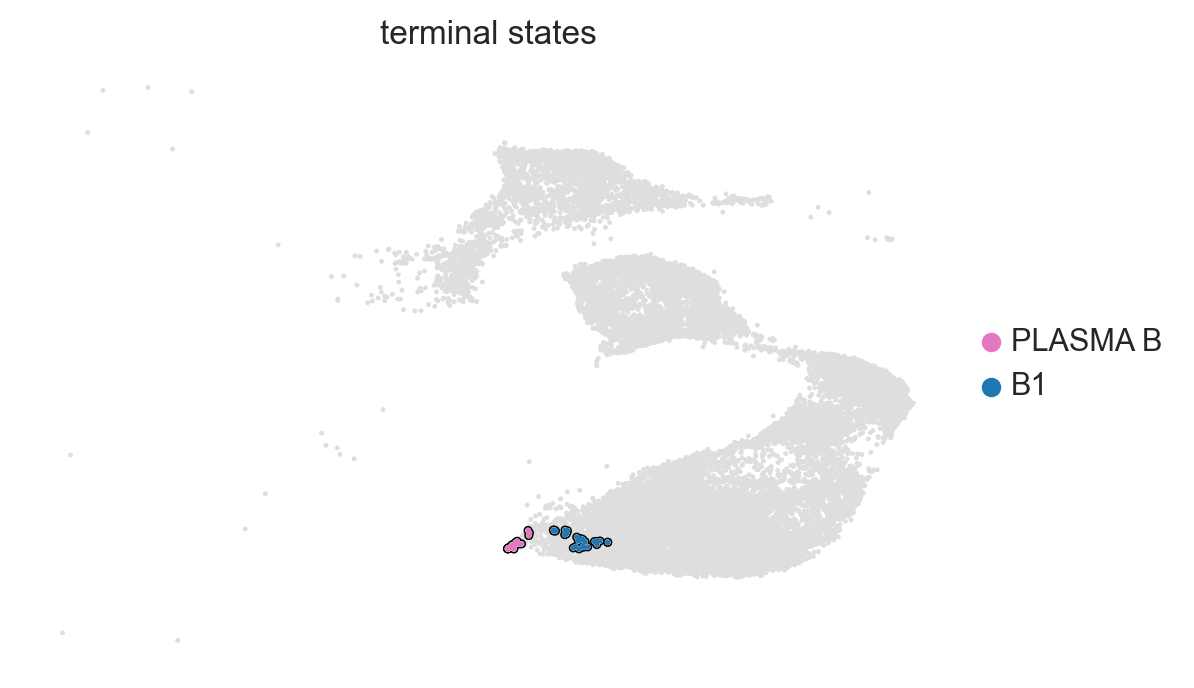

/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


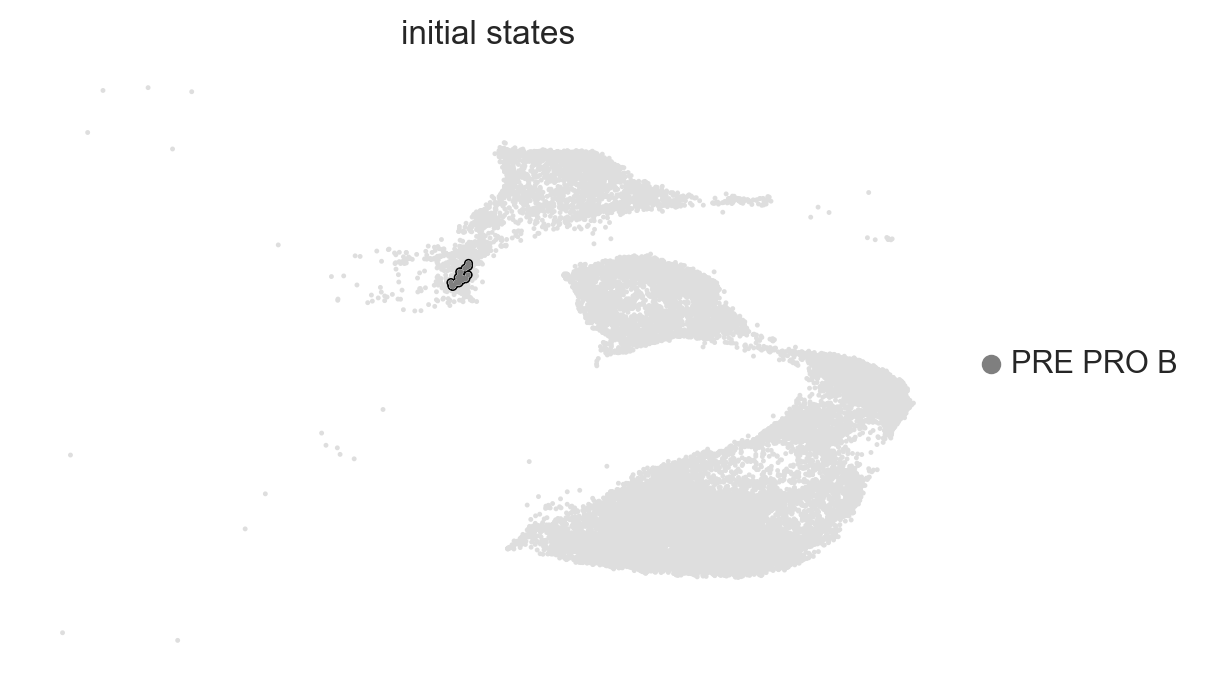

In [24]:
### 根据q_score决定macrostates中的terminal states

from cellrank.estimators import GPCCA
import re
## 计算合并后的kernel
# combined_kernel = 0.9 * lp_kernel + 0.1 * k_bcr
# g = GPCCA(combined_kernel)

## 这里暂时单独使用lp_kernel
g = GPCCA(lp_kernel)
# 一般建议 n_states 不要太大，和 cluster 数量同一个量级即可，比如：
n_macrostates = 15  # 可以调 5~10，看稳定区间
g.fit(n_states=n_macrostates, cluster_key=celltype_key)
# 把 macrostates 写回 obs
adata.obs["macrostate"] = g.macrostates
# print(adata.obs["macrostate"].value_counts(dropna=False).head())
q_key = 'q_score'

# 统计每个 macrostate 的平均 q_score
df_ms = (
    adata.obs
    .dropna(subset=["macrostate"])
    .groupby("macrostate")[q_key]
    .agg(["median", "count"])
    .rename(columns={"median": "q_median", "count": "n_cells"})
    .sort_values("q_median", ascending=False)
)

print(df_ms.head(10))

# 1. 把 macrostate → cell-type
def ms_to_ct(ms):
    # 去掉最后一个 _数字
    return re.sub(r'_\d+$', '', str(ms))

# 2. 整个数据集里，按 cell-type 算 q-score 中位数
ct_q_med = adata.obs.groupby(celltype_key)[q_key].median()

# 3. 给每个 macrostate 打分（用其对应 cell-type 的中位数）
macro_scores = (
    pd.Series(
        {ms: ct_q_med[ms_to_ct(ms)]               # index: macrostate 名
         for ms in adata.obs["macrostate"].dropna().unique()}
    )
    .sort_values(ascending=False)
)
print("macrostate → 对应 cell-type 的 q-score 中位数")
print(macro_scores.head(10))

# ---- 4. 挑 start：macrostate 名里含 start_type，且对应 cell-type 中位数最高 ----
mask = macro_scores.index.astype(str).str.contains(start_type, na=False, regex=False)
start_candidates = macro_scores[mask]
if not start_candidates.empty:
    # raise ValueError(f"没有任何 macrostate 包含 start_type='{start_type}'")
    start_state = start_candidates.index[0]          # 最高分那个
    print("选中的起始 macrostate:", start_state)
    g.set_initial_states(states=[start_state])

# ---- 5. 挑 terminal：排除 start_state 后，取 top-K ----
K = 2
terminal_candidates = macro_scores.head(K)
top_ms = terminal_candidates.index.tolist()
print("候选 terminal macrostates:", top_ms)


# 用 set_terminal_states 显式指定
g.set_terminal_states(states=top_ms)

# 也可以先不指定，让 g.predict_terminal_states  refinement 一次
# g.predict_terminal_states(method="top_n", n_states=K)
g.compute_fate_probabilities()
# fate prob 写在 adata.obs[f"fate_{macrostate}"] 或 g.fate_probabilities
print(g.terminal_states)

g.plot_macrostates(which="terminal", legend_loc="right")
g.plot_macrostates(which='initial', legend_loc="right")

In [25]:
# 1. 保证已经算过 Schur / 平稳分布
# if 'stationary_dist' not in g.eigendecomposition:
#     g.compute_eigendecomposition(k=20)      # k 随意，只要能把平稳分布算出来

b1_drivers = g.compute_lineage_drivers(lineages='PLASMA_B',)
b1_drivers.head(10)

Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:02)


,PLASMA_B_corr,PLASMA_B_pval,PLASMA_B_qval,PLASMA_B_ci_low,PLASMA_B_ci_high
IGHM,0.679143,0.0,0.0,0.672541,0.685636
SEC11C,0.549742,0.0,0.0,0.541205,0.558165
IGKC,0.534553,0.0,0.0,0.525816,0.543177
KLHL14,0.509898,0.0,0.0,0.500849,0.518836
SSR4,0.501499,0.0,0.0,0.492347,0.510541
HSP90B1,0.498894,0.0,0.0,0.489711,0.507967
PPIB,0.494521,0.0,0.0,0.485284,0.503647
MZB1,0.493988,0.0,0.0,0.484745,0.503120
JCHAIN,0.478663,0.0,0.0,0.469240,0.487977
SEC61B,0.476159,0.0,0.0,0.466707,0.485502


In [26]:
HOUSEKEEPING_PREFIXES = ('RPL', 'RPS', 'MRPL', 'MRPS', 'MT-', 'MT.')
# 可选：补充一份手动的 housekeeping 列表
HOUSEKEEPING_EXTRA = {
    'ACTB', 'GAPDH', 'B2M', 'RPLP0', 'EEF1A1', 'EEF1A2',
    'TPT1', 'UBC', 'RPL13A'
}
df = b1_drivers.copy()
df['gene'] = df.index
def is_housekeeping(gene: str) -> bool:
    if gene in HOUSEKEEPING_EXTRA:
        return True
    return gene.startswith(HOUSEKEEPING_PREFIXES)

def filter_housekeeping(df: pd.DataFrame) -> pd.DataFrame:
    mask = ~df['gene'].astype(str).apply(is_housekeeping)
    return df.loc[mask].reset_index(drop=True)

df_k1_filt = filter_housekeeping(df)

# -------------------------------------------------------------------
# 3. 选取各自 top N 候选基因（过滤后）
# -------------------------------------------------------------------
top_n = 20  # 自行调整
top_k1_genes = df_k1_filt.sort_values(f'PLASMA_B_corr', ascending=False)['gene'].head(top_n).tolist()

In [27]:
top_k1_genes

['IGHM',
 'SEC11C',
 'IGKC',
 'KLHL14',
 'SSR4',
 'HSP90B1',
 'PPIB',
 'MZB1',
 'JCHAIN',
 'SEC61B',
 'ADTRP',
 'QPCT',
 'FKBP11',
 'CCR10',
 'CHPF',
 'LINC01480',
 'MYDGF',
 'IGLC2',
 'SDF2L1',
 'SUB1']

Computing trends using `1` core(s)


  0%|          | 0/9 [00:00<?, ?gene/s]

    Finish (0:00:02)
Plotting trends


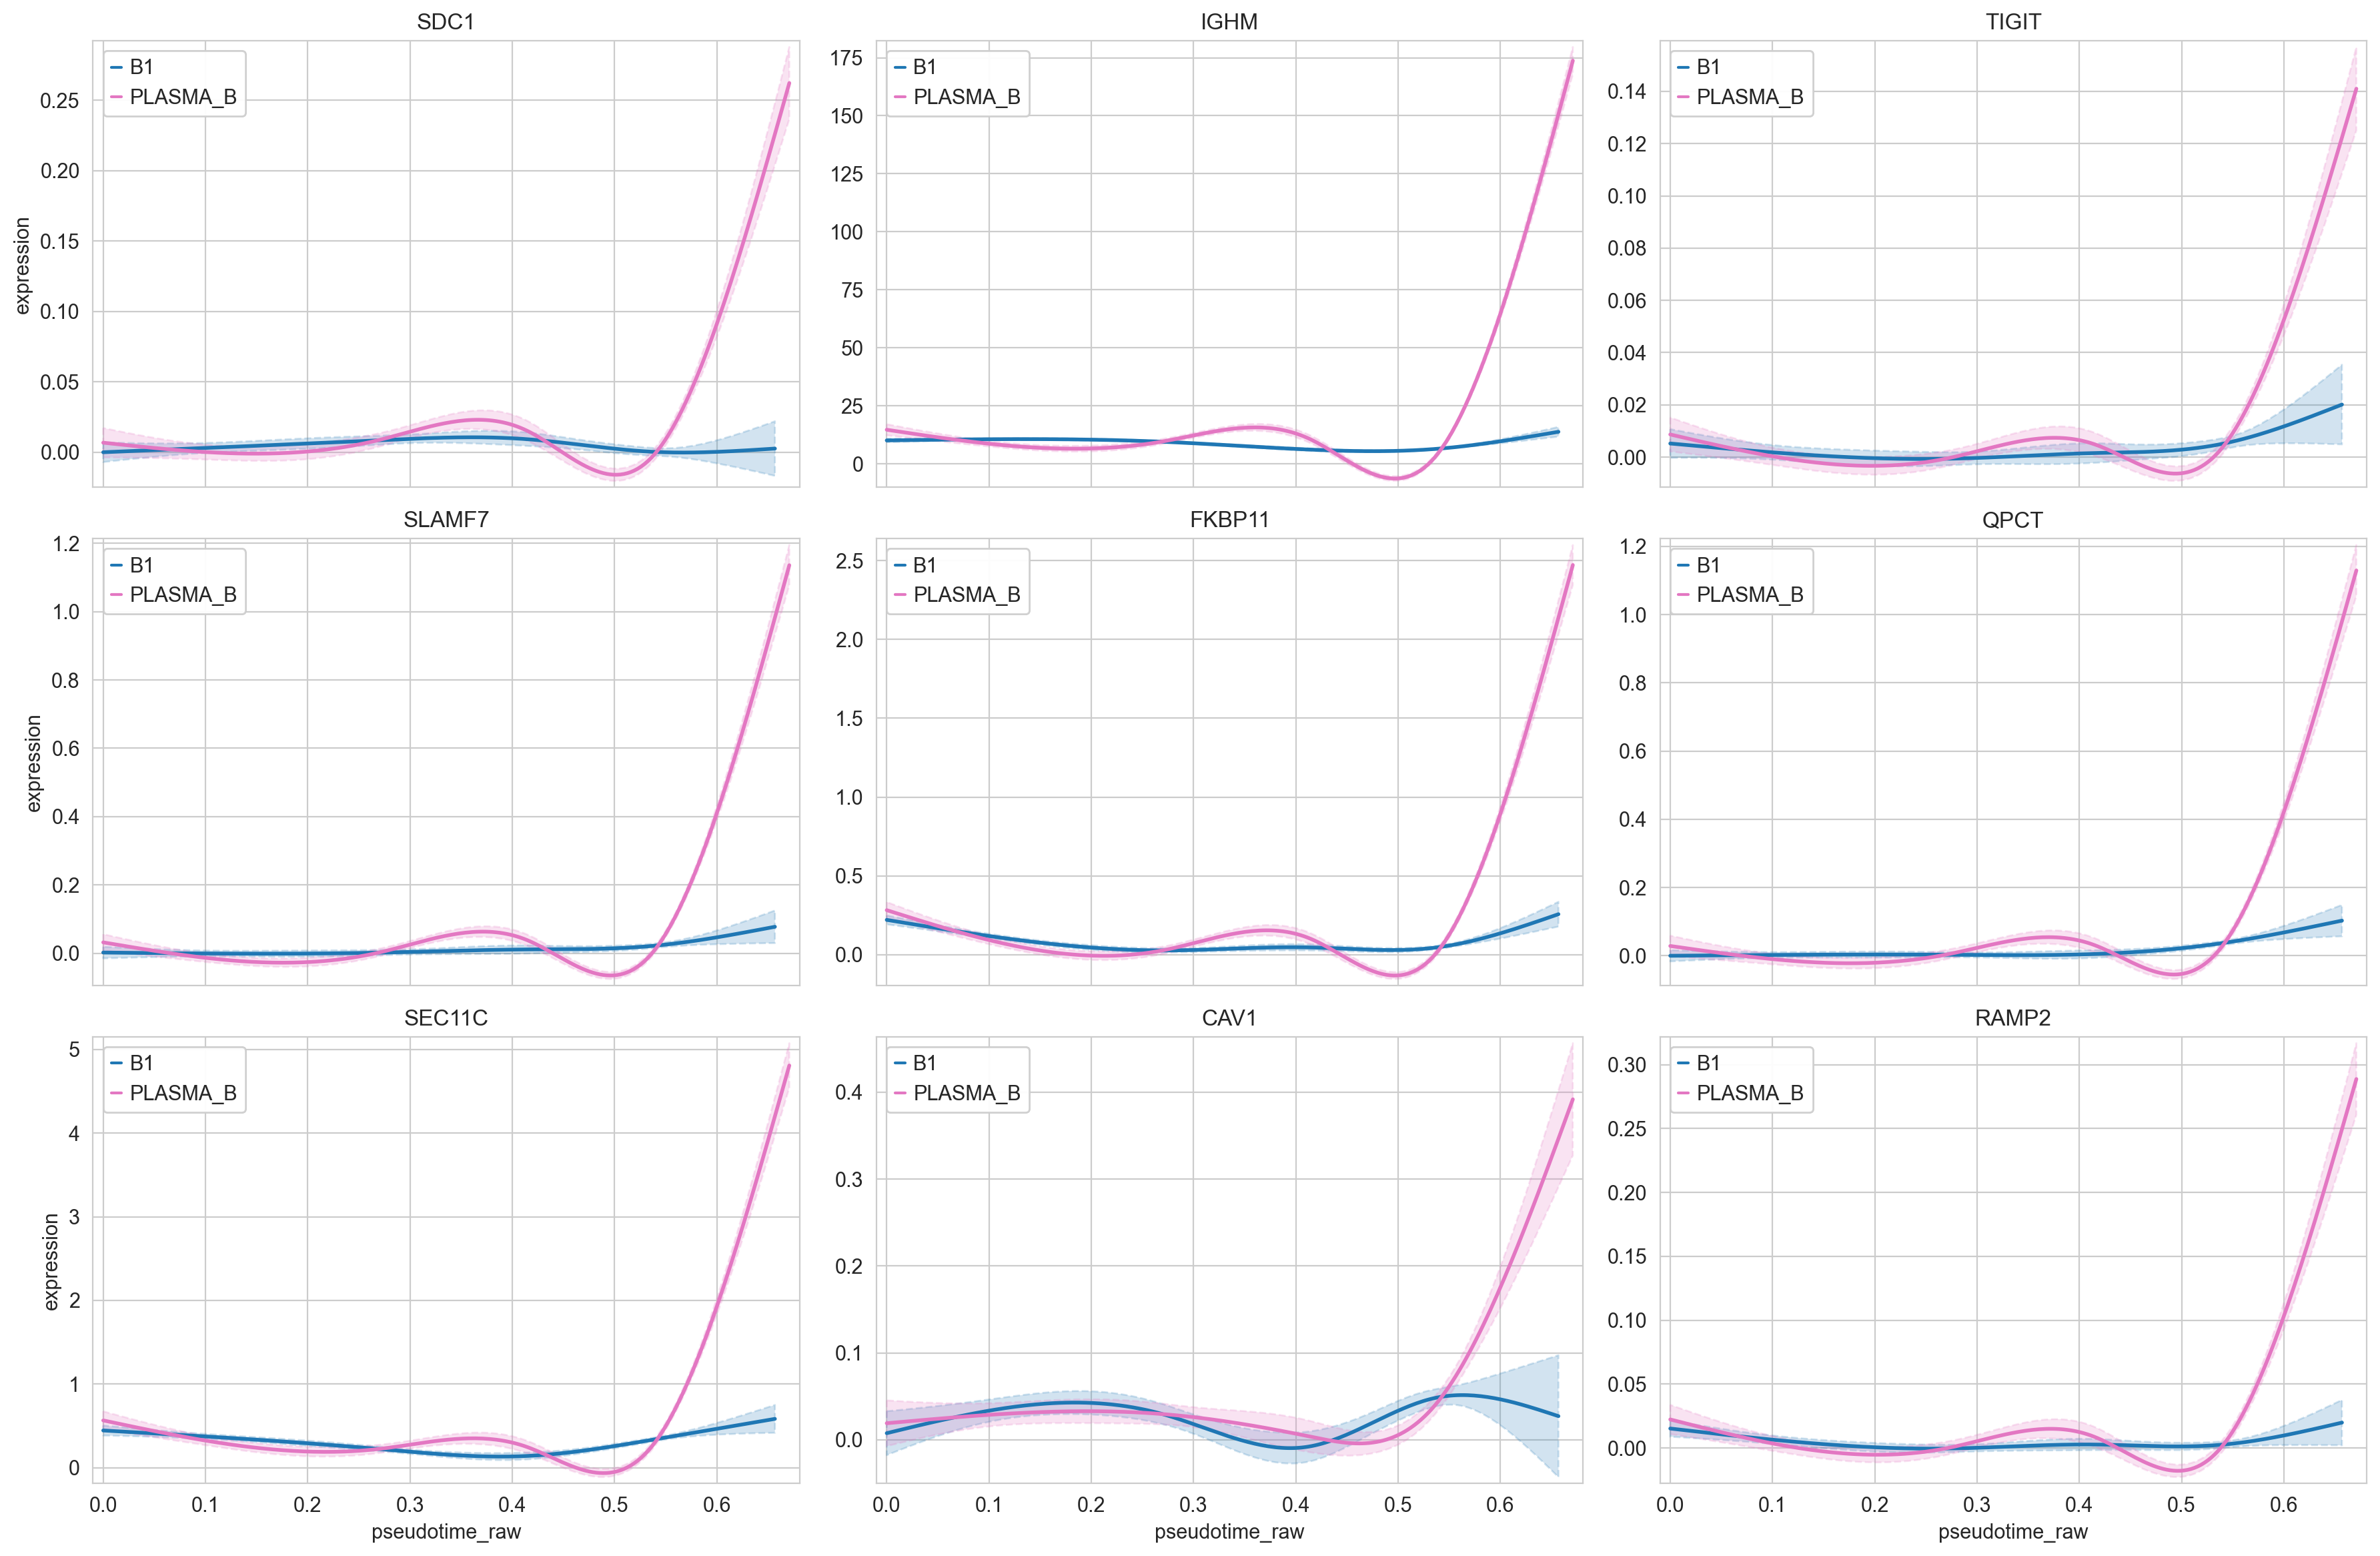

In [29]:
import matplotlib.pyplot as plt
model = cr.models.GAMR(adata)

with plt.rc_context():

    PLASMA_CORE = ['SDC1', 'IGHM', 'TIGIT', 'SLAMF7',
                  'FKBP11', 'QPCT', 'SEC11C', 'CAV1',
                   'RAMP2'
                   ]
    cr.pl.gene_trends(
        adata,
        model=model,
        # lineages = 'PLASMA_B',
        data_key="X",
        genes=PLASMA_CORE,
        same_plot=True,
        ncols=3,
        time_key="pseudotime_raw",
        hide_cells=True,
    )

    plt.savefig("./figs/fetal_b_cells_lineage_genes.pdf", bbox_inches="tight", dpi=300)

Computing Schur decomposition
Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:01)
Computing `15` macrostates
Adding `.macrostates`
       `.macrostates_memberships`
       `.coarse_T`
       `.coarse_initial_distribution
       `.coarse_stationary_distribution`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:03:30)
候选 terminal macrostates: ['PLASMA_B']
Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`
Computing eigendecomposition of the transition matrix
Adding `adata.uns['eigendecomposition_fwd']`
       `.eigendecomposition`
    Finish (0:00:01)
Computing fate probabilities


  0%|          | 0/1 [00:00<?, ?/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)
Adding `adata.varm['terminal_lineage_drivers']`
       `.lineage_drivers`
    Finish (0:00:01)
Computing trends using `1` core(s)


  0%|          | 0/20 [00:00<?, ?gene/s]

    Finish (0:00:02)


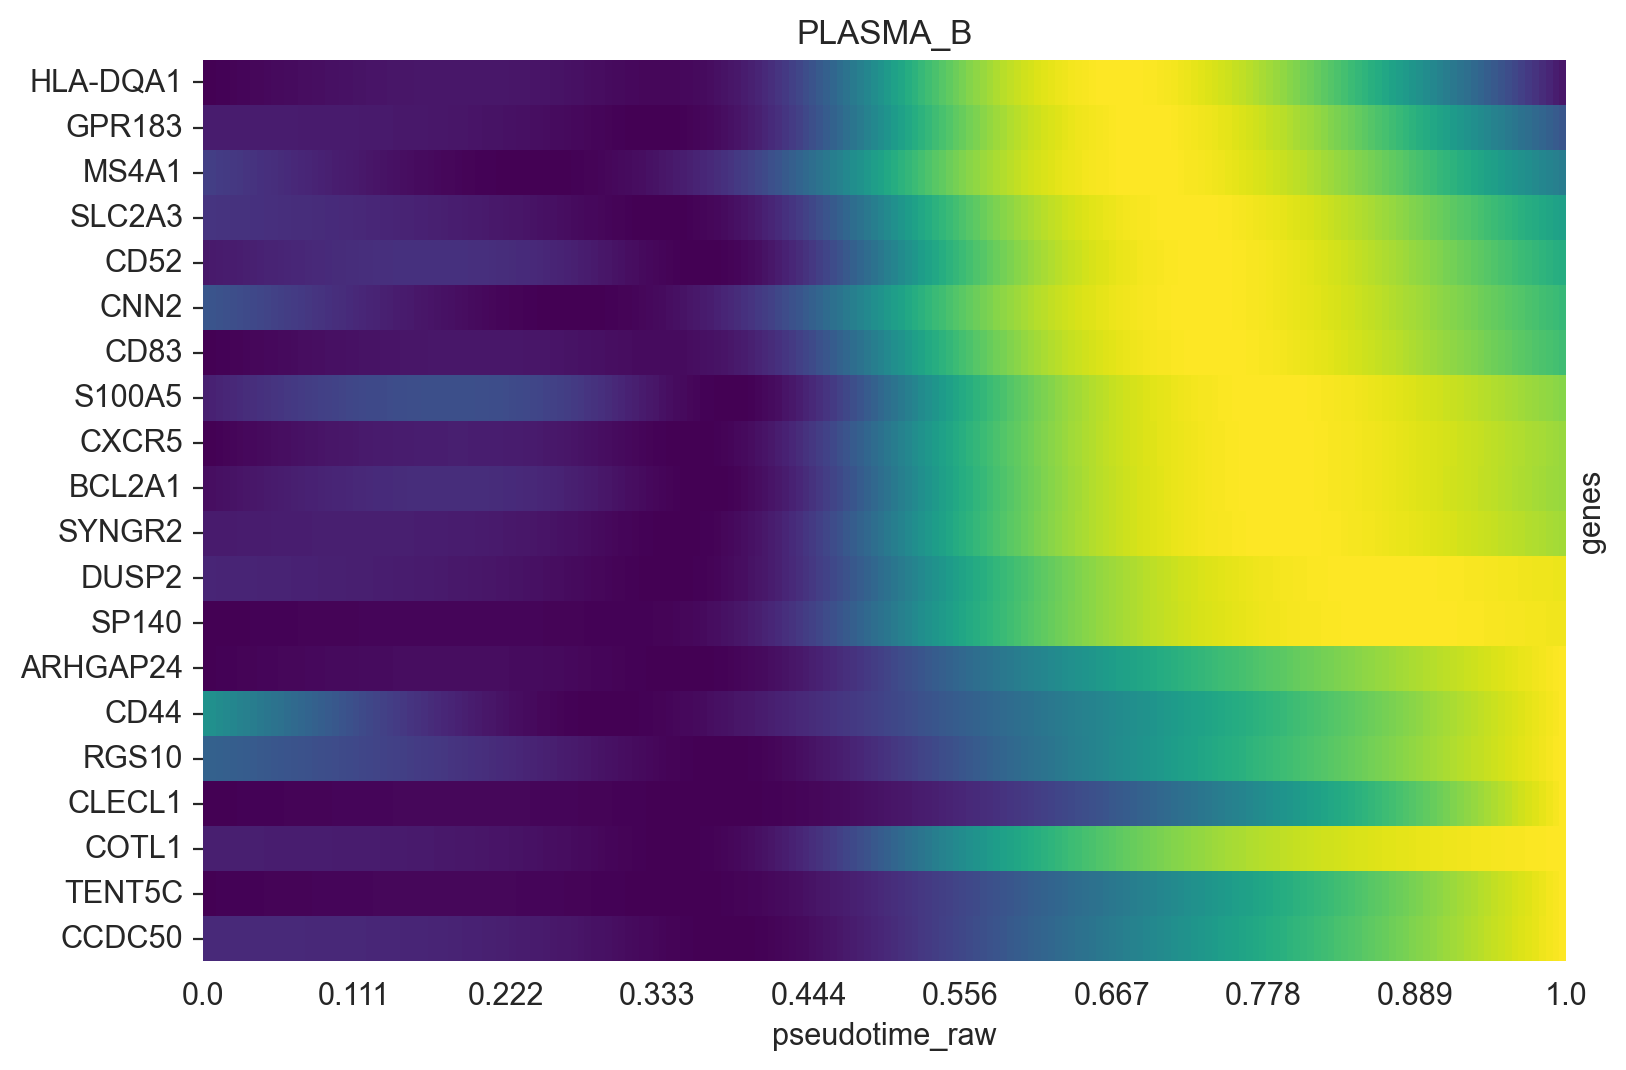

In [31]:
g = GPCCA(lp_kernel)
# 一般建议 n_states 不要太大，和 cluster 数量同一个量级即可，比如：
n_macrostates = 15  # 你可以调 5~10，看稳定区间
g.fit(n_states=n_macrostates, cluster_key=celltype_key)
K = 1  ## 这里只选择 plasma cells作为终点
terminal_candidates = macro_scores.head(K)
top_ms = terminal_candidates.index.tolist()
print("候选 terminal macrostates:", top_ms)

g.set_terminal_states(states=top_ms)
# 1. 保证已经算过 Schur / 平稳分布
g.compute_eigendecomposition(k=20)      # k 随意，只要能把平稳分布算出来
# 2. 命运概率（就是 lineage 概率）
g.compute_fate_probabilities()

b1_drivers = g.compute_lineage_drivers( lineages='PLASMA_B',)

HOUSEKEEPING_PREFIXES = ('RPL', 'RPS', 'MRPL', 'MRPS', 'MT-', 'MT.')
HOUSEKEEPING_EXTRA = {
    'ACTB', 'GAPDH', 'B2M', 'RPLP0', 'EEF1A1', 'EEF1A2',
    'TPT1', 'UBC', 'RPL13A'
}
df = b1_drivers.copy()
df['gene'] = df.index


df_k1_filt = filter_housekeeping(df)

# -------------------------------------------------------------------
# 3. 选取各自 top N 候选基因（过滤后）
# -------------------------------------------------------------------
# top_n = 20  # 自行调整
# top_k1_genes = df_k1_filt.sort_values(f'PLASMA_B_corr', ascending=False)['gene'].head(top_n).tolist()
genes = [
    "CD52",
    "MS4A1",
    "HLA-DQA1",
    "CNN2",
    "SLC2A3",
    "GPR183",
    "CD83",
    "SYNGR2",
    "COTL1",
    "SP140",
    "CXCR5",
    "BCL2A1",
    "DUSP2",
    "ARHGAP24",
    "CD44",
    "RGS10",
    "CLECL1",
    "S100A5",
    "TENT5C",
    "CCDC50"
]

with plt.rc_context():                       # 可选：防止改全局 rc
    cr.pl.heatmap(
        adata,
        model=model,
        data_key="X",
        lineages = 'PLASMA_B',
        # genes=top_k1_genes,
        genes=genes,
        time_key="pseudotime_raw",
        cbar=False,
        show_all_genes=True,
        figsize=(10, 6),
        # show=False,                        # 关键：不弹窗
    )
    plt.savefig("./figs/fetal_b_cells_lineage_heatmap.pdf", bbox_inches="tight", dpi=300)